<a href="https://colab.research.google.com/github/zaidlameer/DeetectorPrototype/blob/main/audioTrainingV3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# prompt: mount my drive

from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
!pip install resampy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 46.9 MB/s eta 0:00:00


In [3]:
import numpy as np
import pandas as pd
import os
import librosa
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import IPython
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import RandomOverSampler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation, Dropout, Conv2D, MaxPool2D, Flatten
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping

In [6]:
audio_files_path = "/content/drive/MyDrive/audio_dataset_train"

In [7]:
folders = os.listdir(audio_files_path)
print(folders)

['FAFV_audio_test', 'RAFV_audio_test']


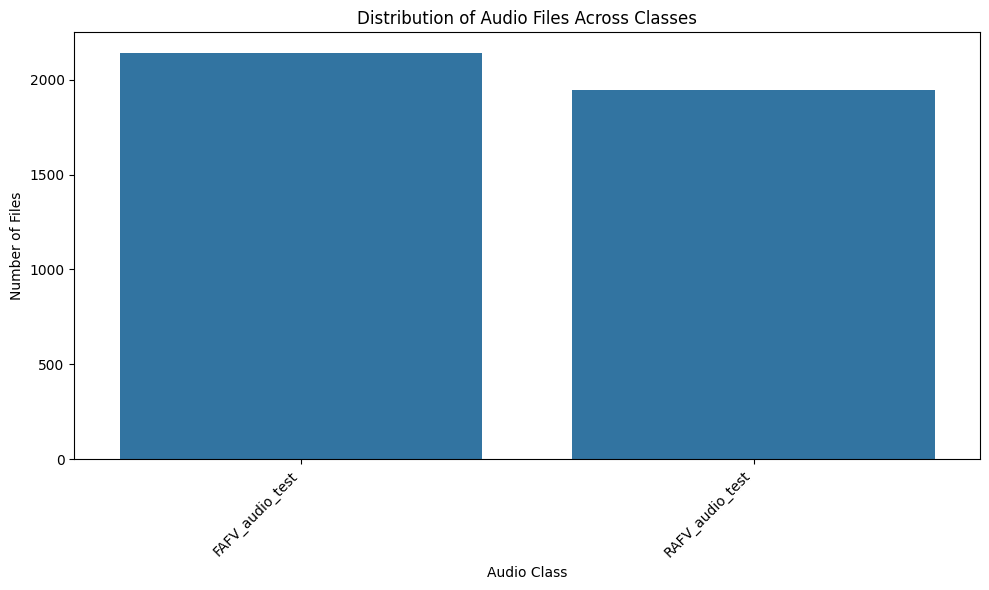

In [8]:
# prompt: plot the file distribution in /content/drive/MyDrive/audio_dataset_train

# Count the number of files in each folder
file_counts = {}
for folder in folders:
    folder_path = os.path.join(audio_files_path, folder)
    if os.path.isdir(folder_path):  # Check if it's a directory
        file_count = len(os.listdir(folder_path))
        file_counts[folder] = file_count

# Create a bar plot
plt.figure(figsize=(10, 6))
sns.barplot(x=list(file_counts.keys()), y=list(file_counts.values()))
plt.xlabel("Audio Class")
plt.ylabel("Number of Files")
plt.title("Distribution of Audio Files Across Classes")
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for readability
plt.tight_layout()
plt.show()


In [9]:
data = []
labels = []

for folder in folders:
    files = os.listdir(os.path.join(audio_files_path, folder))
    for file in tqdm(files):
        file_path = os.path.join(audio_files_path, folder, file)
        audio, sample_rate = librosa.load(file_path, res_type="kaiser_fast")
        mfccs_features = librosa.feature.mfcc(y=audio, sr=sample_rate, n_mfcc=40)
        mfccs_features_scaled = np.mean(mfccs_features.T, axis=0)
        data.append(mfccs_features_scaled)
        labels.append(folder)

100%|██████████| 1944/1944 [04:47<00:00,  6.76it/s]


In [10]:
feature_df = pd.DataFrame({"features": data, "class": labels})
feature_df.head()

,features,class
0,"[-425.91455, 145.26587, -7.5328226, 43.268097,...",FAFV_audio_test
1,"[-341.20822, 151.17548, -47.64038, 28.79596, -...",FAFV_audio_test
2,"[-423.03345, 141.75781, -70.46728, 32.925354, ...",FAFV_audio_test
3,"[-409.35638, 127.65234, -17.48836, 41.926285, ...",FAFV_audio_test
4,"[-358.1673, 170.01562, -16.889256, 30.090183, ...",FAFV_audio_test


In [11]:
feature_df["class"].value_counts()

,count
class,
FAFV_audio_test,2143
RAFV_audio_test,1944


In [12]:
def label_encoder(column):
    le = LabelEncoder().fit(column)
    print(column.name, le.classes_)
    return le.transform(column)

In [13]:
feature_df["class"] = label_encoder(feature_df["class"])

class ['FAFV_audio_test' 'RAFV_audio_test']


In [14]:
X = np.array(feature_df["features"].tolist())
y = np.array(feature_df["class"].tolist())

ros = RandomOverSampler(random_state=42)
X_resampled, y_resampled = ros.fit_resample(X, y)

y_resampled = to_categorical(y_resampled)

X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

num_labels = len(feature_df["class"].unique())
num_labels



2

In [15]:
input_shape = feature_df["features"][0].shape
input_shape

(40,)

In [16]:
model = Sequential()
model.add(Dense(128, input_shape=input_shape))
model.add(Activation(activation="relu"))
model.add(Dropout(0.5))
model.add(Dense(256))
model.add(Activation(activation="relu"))
model.add(Dropout(0.5))
model.add(Dense(128))
model.add(Activation(activation="relu"))
model.add(Dropout(0.5))
model.add(Dense(num_labels))
model.add(Activation(activation="softmax"))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [17]:
model.compile(loss="categorical_crossentropy", optimizer="adam", metrics=["accuracy"])

In [18]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 128)                 │           5,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation (Activation)              │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 256)                 │          33,024 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_1 (Activation)            │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_2 (Activation)            │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 2)                   │             258 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_3 (Activation)            │ (None, 2)                   │               0 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 71,426 (279.01 KB)

 Trainable params: 71,426 (279.01 KB)

 Non-trainable params: 0 (0.00 B)

In [19]:
early = EarlyStopping(monitor="val_loss", patience=5)

In [20]:
history = model.fit(X_train, y_train, validation_data=(X_test, y_test), batch_size=2, epochs=100, callbacks=[early])

Epoch 1/100
1714/1714 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.5485 - loss: 9.9523 - val_accuracy: 0.6072 - val_loss: 0.6686
Epoch 2/100
1714/1714 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.6206 - loss: 0.7129 - val_accuracy: 0.7890 - val_loss: 0.5376
Epoch 3/100
1714/1714 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7371 - loss: 0.5411 - val_accuracy: 0.7646 - val_loss: 0.4874
Epoch 4/100
1714/1714 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.7861 - loss: 0.4646 - val_accuracy: 0.8415 - val_loss: 0.3807
Epoch 5/100
1714/1714 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8103 - loss: 0.4481 - val_accuracy: 0.8823 - val_loss: 0.3523
Epoch 6/100
1714/1714 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8286 - loss: 0.4004 - val_accuracy: 0.8520 - val_loss: 0.3135
Epoch 7/100
1714/1714 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.8336 - loss: 0.3844 - val_accuracy: 0.8788 - val_loss: 0.2907
Epoch 8/100
1714/1714 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8492 - loss: 

In [21]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)

27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.9500 - loss: 0.1244
Test Loss: 0.13290221989154816
Test Accuracy: 0.9487179517745972


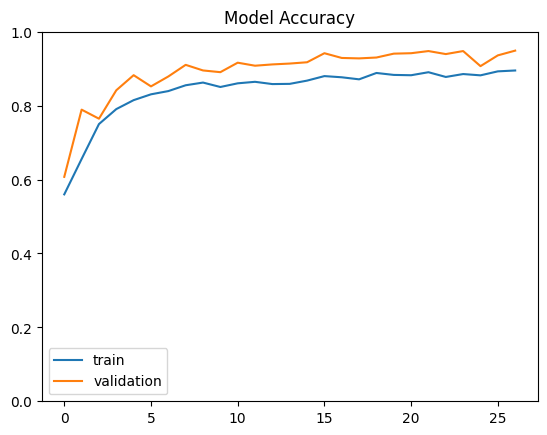

In [22]:
plt.figure()
plt.title("Model Accuracy")
plt.plot(history.history["accuracy"], label="train")
plt.plot(history.history["val_accuracy"], label="validation")
plt.legend()
plt.ylim([0, 1])
plt.show()

In [23]:
def detect_fake(filename):
    sound_signal, sample_rate = librosa.load(filename, res_type="kaiser_fast")
    mfcc_features = librosa.feature.mfcc(y=sound_signal, sr=sample_rate, n_mfcc=40)
    mfccs_features_scaled = np.mean(mfcc_features.T, axis=0)
    mfccs_features_scaled = mfccs_features_scaled.reshape(1, -1)
    result_array = model.predict(mfccs_features_scaled)
    print(result_array)
    result_classes = ["FAKE", "REAL"]
    result = np.argmax(result_array[0])
    print("Result:", result_classes[result])

In [27]:
test_fake = "/content/drive/MyDrive/audio_files/FARV_audio_train/00001_fake_1.flac"
test_real = "/content/drive/MyDrive/audio_files/RAFV_audio_test/00001_id00325_4vJtbNe0L98.flac"

In [29]:
detect_fake(test_fake)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step
[[0.92313176 0.07686821]]
Result: FAKE


In [30]:
# prompt: save this model in an optimal format

model.save('audio_classification_model.h5')
